## 1. 분류모형을 위한 전처리-Imbalanced

In [202]:
!pip install imblearn -q

In [203]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
data = pd.read_csv("data_semiconductor.csv")
data.head()


,X20,X86,X87,X88,X113,X115,X116,X117,X119,X120,...,X527,X570,X571,X572,X573,X574,X575,X576,X577,Pass.Fail
0,1.4026,2.3895,0.9690,1747.6049,0.9460,748.6115,0.9908,58.4306,0.9804,6.3788,...,6.6926,533.8500,2.1113,8.95,0.3157,3.0624,0.1026,1.6765,14.9509,0
1,1.3825,2.3754,0.9894,1931.6464,0.9425,731.2517,0.9902,58.6680,0.9731,6.5061,...,8.8370,535.0164,2.4335,5.92,0.2653,2.0111,0.0772,1.1065,10.9003,0
2,1.4123,2.4532,0.9880,1685.8514,0.9231,718.5777,0.9899,58.4808,0.9772,6.4527,...,6.4568,535.0245,2.0293,11.21,0.1882,4.0923,0.0640,2.0952,9.2721,1
3,1.4011,2.4004,0.9904,1752.0968,0.9564,709.0867,0.9906,58.6635,0.9761,6.4935,...,6.4865,530.5682,2.0253,9.33,0.1738,2.8971,0.0525,1.7585,8.5831,0
4,1.3888,2.4530,0.9902,1828.3846,0.9424,796.5950,0.9908,58.3858,0.9628,6.3551,...,6.3745,532.0155,2.0275,8.83,0.2224,3.1776,0.0706,1.6597,10.9698,0


In [204]:
data["Pass.Fail"].value_counts()

Pass.Fail
0    1463
1     104
Name: count, dtype: int64

In [205]:
smote = SMOTE(sampling_strategy=0.4, k_neighbors=5)
X, y = smote.fit_resample(data.drop("Pass.Fail", axis=1), data["Pass.Fail"])

In [206]:
X.shape, y.shape

((2048, 48), (2048,))

In [207]:
smote = RandomUnderSampler(sampling_strategy=0.4) #다수 클래스의 샘플 수를 소수 클래스의 샘플 수의 0.4배만큼 남기
X, y = smote.fit_resample(data.drop("Pass.Fail", axis=1), data["Pass.Fail"])

In [208]:
X.shape, y.shape

((364, 48), (364,))

## 2. 파일 및 폴더 다루기 (리뷰)

In [209]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os

In [210]:
import glob

def read_custom_csv(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # 데이터가 시작되는 줄 번호 찾기 (e.g., 'Data Leng' 포함된 줄)
    start_idx = next(i for i, line in enumerate(lines) if "Data Length" in line) + 1

    # 시간 + 센서값 부분을 pandas로 읽기
    df = pd.read_csv(filepath, skiprows=start_idx, header=None)

    # 시간 컬럼 이름 지정
    num_columns = df.shape[1]
    col_names = ['time'] + [f'sensor_{i}' for i in range(1, num_columns)]
    df.columns = col_names
    return df

In [211]:
# 여러 파일 읽고 하나로 합치기
def read_file( base_dir):
  all_files = glob.glob(os.path.join(base_dir, "*.csv"))
  df_list = [read_custom_csv(f) for f in all_files]
  df_all = pd.concat(df_list, ignore_index=True)
  return df_all


In [212]:
base_dir = os.path.join("manufacturing", "벨트느슨함")
df1 = read_file(base_dir)
df1["target"] = "abnormal"
base_dir = os.path.join("manufacturing", "정상")
df2 = read_file(base_dir)
df2["target"] = "normal"

In [213]:
df_final = pd.concat([df1, df2], ignore_index=True)

In [214]:
df_final.shape

(502000, 6)

## 2. 분류 Overview

 - 분류(Classification) : 학습데이터로 주어진 데이터의 피처와 라벨 값(범주값)을 머신러닝 알고리즘으로 학습 / 모델에 새로운 피쳐(feature) 값이 주어지면 라벨 값(범주)를 예측. 다양한 분류 알고리즘이 있으며 많이 활용되고 있음

0. 선형모형
 - 로지스틱 회귀(Logistic Regression): 독립변수와 종속변수의 선형 관계성에 기반

1. Tree 기반 모형
 - 결정나무(Decision Tree): 타겟 변수 범주 분포의 균일함에 대한 규칙 기반
 - 랜덤 포레스트(Random Forest): Tree 모형들을 결합한 앙상블(Ensemble) 모형 중 배깅 모형

2. 확률과 거리 기반
 - 나이브 베이즈(Naive Bayes): 베이즈(Bayes) 통계 기반
 - KNN: 근접 거리를 기준으로 하는 근접 이웃 기반 (Nearest Neighbor)

3. 부스팅 모형
 - Adaboost: Tree 등 Weak Learner 모형들을 순차적으로 결합한 앙상블(Ensemble) 모형 중 부스팅
 - Gradient Boosting 등

4. 비선형 & 블랙박스 모형
 - 서포트 벡터 머신(Support Vector machine): 개별 클래스 간의 최대 분류 마진을 효과적으로 발견
 - 인공신경망: 은닉층을 통한 비선형 변환을 통한 분류

 ## 3. Tree 기반 분류: DT와 Random Forest
 - DT: 비교적 쉽게 적용할 수 있는 모형
 - 데이터 스케일링 등 전처리의 영향이 상대적으로 적음
 - 과적합(Overfitting)의 발생
 - 분류(Classification)와 회귀(Regression) 모두 가능
- Tree?
 - Binary Tree?
 - 특정 기준(질문)에 따라 데이터를 구분


- 타겟 변수 범주 분포의 불순도

<figure>
    <img src='https://blog.kakaocdn.net/dn/dhoo7N/btqDvzqEhPH/QdOsfkqc2hcwHISIh0peo1/img.png' width=700 height=300>
</figure>

 - A, B, C 중에서 균일한 정도는? 균일한 순서는? 분류모형과의 의미는?
 - 측정: 엔트로피를 이용한 정보 이득(Information Gain)지수와 지니계수, Chi-square 등등

- 불순도(Impurity)
 - 서로 다른 범주가 얼마나 혼재하는지를 측정


<figure>
    <img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FqLXhZ%2FbtqwWyZl6iV%2FUZnQbf9L5HAFzf6hFfxK71%2Fimg.png' width=400 height=300>
</figure>


 - 엔트로피(Entropy)와 정보이득(Information Gain): 불순도(Impurity)를 측정, 엔트로피가 높으면 불순도가 높음. 엔트로피가 1이면 불순도가 최대. 즉, 한 범주 안에 서로 다른 데이터가 정확히 반반 있음. 엔트로피가 0이면 불순도는 최소. 한 범주 안에 하나의 데이터만 있음. 정보 이득(Information Gain)은 엔트로피를 사용하여 측정, 1에서 엔트로피 지수를 뺀 값으로 1-엔트로피 지수. 정보이득이 높으면 분류가 잘 된 것으로 이해할 수 있음

 - 지니 계수(Gini Index): 불평등 지수를 나타내는 값으로 0이 가장 평등(균일)하고 1에 가까우면 불평등함(다양함). 지니 계수가 낮을수록 데이터 균일도가 높은 상태이므로, 계수가 낮은 feature의 rule을 찾음


### 2.1. sklearn에서 DT의 주요 hyperparameter

1) max_depth
 - 트리의 최대 깊이를 규정
 - 과적합과 관련
 - defualt 는 None이며, 분류가 잘 이뤄질 때까지 깊이를 더해나가고 노드가 가지는 데이터 개수가 min_samples_split 보다 작아질 때까지 게속 깊이를 증가

2) max_features
 - 최적의 분할을 위해 고려할 최대 변수의 개수, 디폴트는 None으로 X변수들의 전체를 사용해 분류
 - int 형: 대상 피처의 개수, float 형: 전체 피처 중 대상 피처의 퍼센트임.
 - 'sqrt': 전체 피처 중 sqrt(전체 피처 개수) 즉 ${\sqrt {전체 피처}}$개수 지정
 - 'auto': sqrt와 동일
 - 'log': 전체 피처 중 log2(전체 피처 개수) 선정
 - 'None': 전체 피처 선정

3) min_samples_split
 - 노드를 분기가 일어나기 위한 최소한의 샘플 데이터 수(node내 observation의 수)로 과적합을 관리하는데 사용할 수 있음
 - 디폴트는 2, 작을 수록 과적합 가능성 증가

4) min_samples_leaf
 - Terminal 노드(leaf)가 되기 위한 최소한의 Obs.의 수
 - min_samples_split와 유사하게 과적합 관리에 활용
 - 불균형 타겟변수에 대한 분류 시 작은 값으로 설정

5) max_leaf_nodes
 - Leaf 최대 개수


6) **CART(Classification And Regression Tree)**
- 지니 지수(Gini Index) 또는 분산의 감소량을 사용하여 분류
- 범주형 변수에 대해서는 지니 계수
- 연속형 변수에 대해서는 분산의 감소량 사용

| 알고리즘 | 평가지수(선택방법) | 비고 |
|:---:|:----:|:----|
| ID3 | Entropy | 다지분리(범주) |
| C4.5 | Information Gain | 다지분리(범주) 및 이진분리(수치) |
| C5.0 | 카이제곱(범주), F검정(수치) | 통계적 접근 방식
| CART | Gini index(범주), 분산의 차이(수치) |통계적 접근 방식, 항상 2진 분리|



### 2.2. 가상의 데이터로 분류

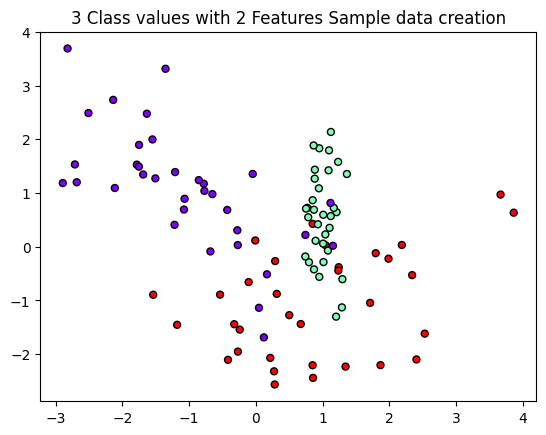

In [215]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title("3 Class values with 2 Features Sample data creation")

# 2차원 시각화를 위해서 feature는 2개, 결정값 클래스는 3가지 유형의 classification 샘플 데이터 생성.
X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2,
                             n_classes=3, n_clusters_per_class=1,random_state=0)

# plot 형태로 2개의 feature로 2차원 좌표 시각화, 각 클래스값은 다른 색깔로 표시됨.
plt.scatter(X_features[:, 0], X_features[:, 1], marker='o', c=y_labels, s=25, cmap='rainbow', edgecolor='k')

In [216]:
import numpy as np

# Classifier의 Decision Boundary를 시각화 하는 함수
def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()

    # 학습 데이타 scatter plot으로 나타내기
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()

    # 호출 파라미터로 들어온 training 데이타로 model 학습 .
    model.fit(X, y)

    # meshgrid 형태인 모든 좌표값으로 예측 수행.
    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # contourf() 를 이용하여 class boundary 를 visualization 수행.
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow', clim=(y.min(), y.max()),
                           zorder=1)

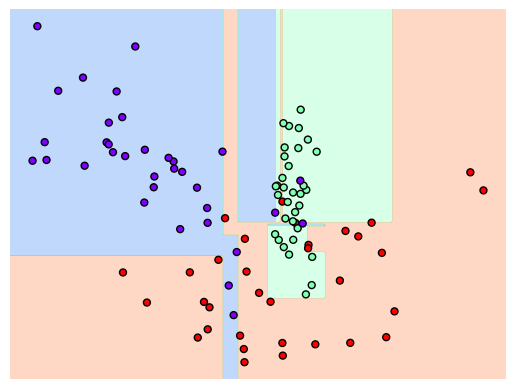

In [217]:
from sklearn.tree import DecisionTreeClassifier

# 특정한 트리 생성 제약없는 결정 트리의 Decsion Boundary 시각화.
dt_clf = DecisionTreeClassifier().fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

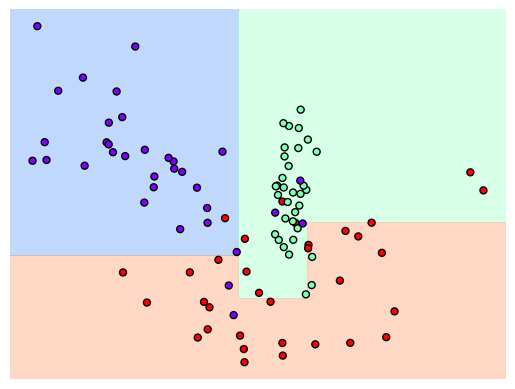

In [218]:
# 하이퍼파라미터를 변경하며 수행: 예) min_samples_leaf=6 으로 트리 생성 조건을 제약한 Decision Boundary 시각화
dt_clf = DecisionTreeClassifier( min_samples_leaf=6).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

### 2.3. 예제2

In [219]:
import pandas as pd
import numpy as np
# 데이터 정의
data = pd.DataFrame({"no_insects":["True","True","True","False","True","True","True","True","True","False"],
                     "no_dead":["True","True","False","True","True","True","False","False","True","False"],
                     "no_wilting":["True","True","True","True","True","True","False","True","True","True"],
                     "no_diseases":["True","True","False","True","True","True","False","False","True","True"],
                     "tree_health":["Good","Good","Poor","Good","Good","Good","Poor","Poor","Good","Poor"]},
                    columns=["no_insects","no_dead","no_wilting","no_diseases","tree_health"])
# 기술 속성(descriptive features)
features = data[["no_insects","no_dead","no_wilting","no_diseases"]]
# 대상 속성(target feature)
target = data["tree_health"]
print(data)


  no_insects no_dead no_wilting no_diseases tree_health
0       True    True       True        True        Good
1       True    True       True        True        Good
2       True   False       True       False        Poor
3      False    True       True        True        Good
4       True    True       True        True        Good
5       True    True       True        True        Good
6       True   False      False       False        Poor
7       True   False       True       False        Poor
8       True    True       True        True        Good
9      False   False       True        True        Poor


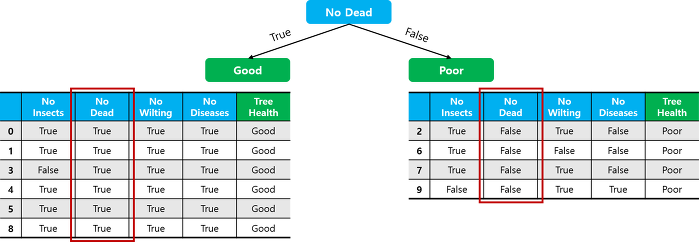

In [220]:
# 엔트로피
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts = True)
    entropy = -np.sum([(counts[i]/np.sum(counts))*np.log2(counts[i]/np.sum(counts)) for i in range(len(elements))])
    return entropy


[Source: statquest 영상]
- 정보 이득: 상위 노드의 엔트로피에서 하위 노드의 엔트로피를 뺀 값

image.png

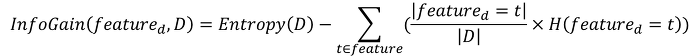

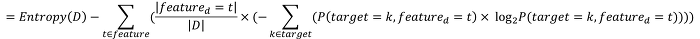

- No Insects 속성의 예

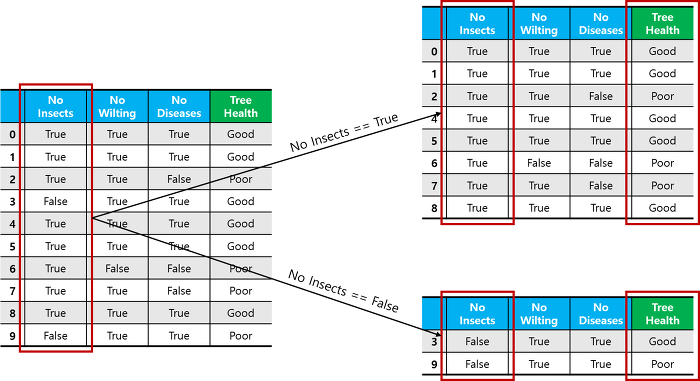

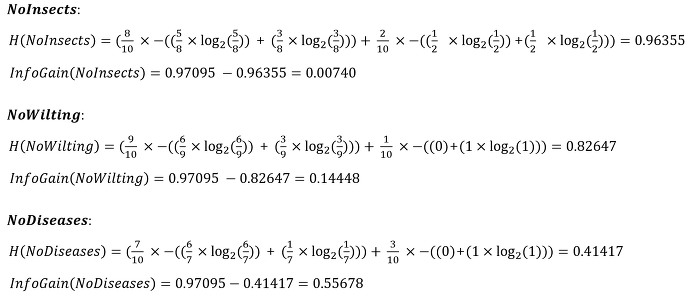

In [221]:
# 정보이득
def InfoGain(data,split_attribute_name,target_name):

    # 전체 엔트로피 계산
    total_entropy = entropy(data[target_name])
    print('Entropy(D) = ', round(total_entropy, 5))

    # 가중 엔트로피 계산
    vals,counts= np.unique(data[split_attribute_name],return_counts=True)
    Weighted_Entropy = np.sum([(counts[i]/np.sum(counts))*
                               entropy(data.where(data[split_attribute_name]==vals[i]).dropna()[target_name])
                               for i in range(len(vals))])
    print('H(', split_attribute_name, ') = ', round(Weighted_Entropy, 5))


    # 정보이득 계산
    Information_Gain = total_entropy - Weighted_Entropy
    return Information_Gain

print('InfoGain( no_insects ) = ', round(InfoGain(data, "no_insects", "tree_health"), 5), '\n')
print('InfoGain( no_wilting ) = ', round(InfoGain(data, "no_wilting", "tree_health"), 5), '\n')
print('InfoGain( no_diseases ) = ', round(InfoGain(data, "no_diseases", "tree_health"), 5))

Entropy(D) =  0.97095
H( no_insects ) =  0.96355
InfoGain( no_insects ) =  0.0074 

Entropy(D) =  0.97095
H( no_wilting ) =  0.82647
InfoGain( no_wilting ) =  0.14448 

Entropy(D) =  0.97095
H( no_diseases ) =  0.41417
InfoGain( no_diseases ) =  0.55678


[Source: statquest 영상]


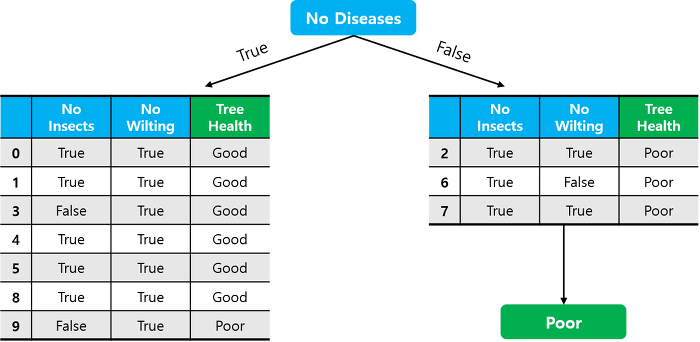

계산방식은 아래와 같음

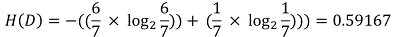

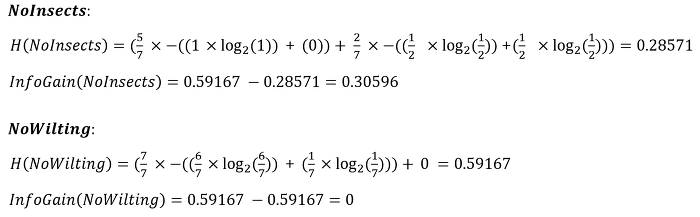

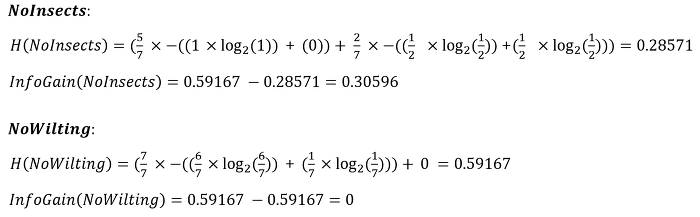

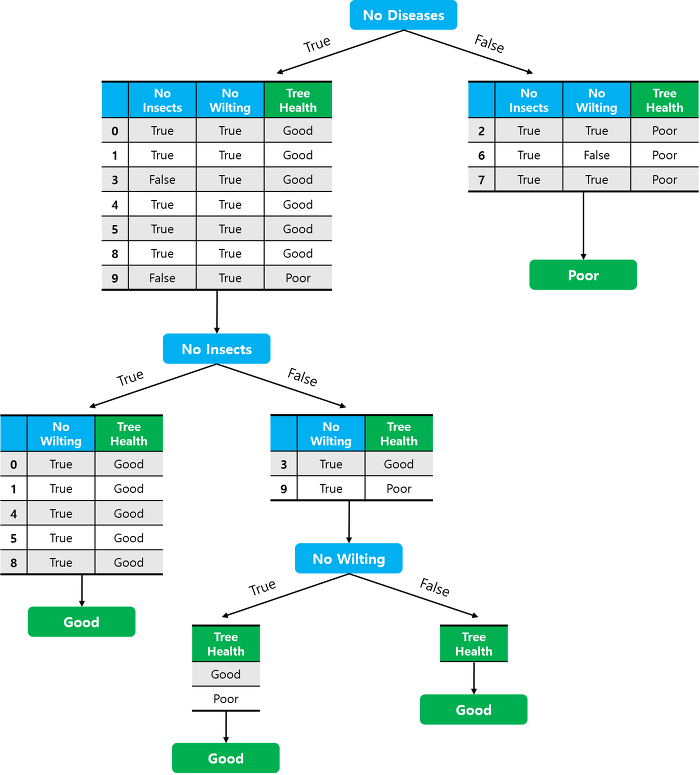

In [222]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

cat_cols = [c for c in features.columns if features[c].dtypes=='O']
num_cols = [c for c in features.columns if features[c].dtypes!='O']

cat_cols

['no_insects', 'no_dead', 'no_wilting', 'no_diseases']

In [223]:
features_enc = features

for i in cat_cols:
  features_enc[i] = LabelEncoder().fit_transform(features[i])

features_enc

dt = DecisionTreeClassifier()
dt.fit( features_enc, target)
dt.score(features_enc, target)
print( dt.tree_.children_left )
print( dt.tree_.children_right )

[ 1 -1 -1]
[ 2 -1 -1]


### 2.4. DT 시각화

In [224]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dt_clf = DecisionTreeClassifier(min_samples_leaf=6,random_state=156)

# iris 데이터
iris_data = load_iris()
X_train , X_test , y_train , y_test = train_test_split(iris_data.data, iris_data.target,
                                                       test_size=0.2,  random_state=11)

# 학습
dt_clf.fit(X_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",156
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [225]:
from sklearn.tree import export_graphviz
# export_graphviz()의 호출 결과로 out_file로 지정된 tree.dot 파일
export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names , \
feature_names = iris_data.feature_names, impurity=True, filled=True)

In [226]:
!pip install graphviz

In [227]:
import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz 읽어서 Jupyter Notebook상에서 시각화
with open("tree.dot") as f:
    dot_graph = f.read()

In [228]:
#graphviz.Source(dot_graph)  #graphviz가 path에 설정되어야 함.

Feature importances:
[0.    0.    0.567 0.433]
sepal length (cm) : 0.000
sepal width (cm) : 0.000
petal length (cm) : 0.567
petal width (cm) : 0.433


<Axes: >

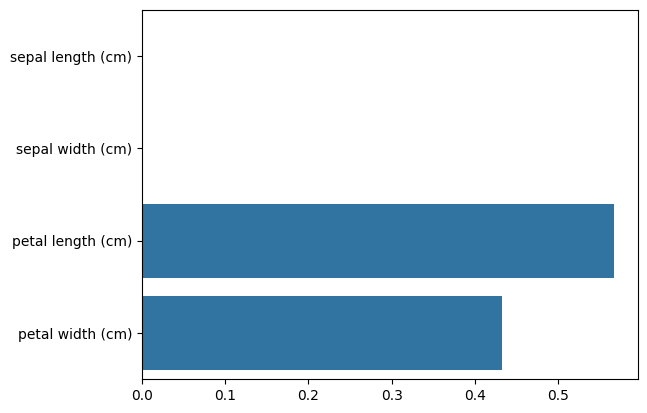

In [229]:
import seaborn as sns
import numpy as np
%matplotlib inline

# feature importance 추출
print("Feature importances:\n{0}".format(np.round(dt_clf.feature_importances_, 3)))

# feature별 importance 매핑
for name, value in zip(iris_data.feature_names , dt_clf.feature_importances_):
    print('{0} : {1:.3f}'.format(name, value))

# feature importance를 column 별로 시각화 하기
sns.barplot(x=dt_clf.feature_importances_ , y=iris_data.feature_names)

### 2.5. Decision Tree와 성능 평가

In [230]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42) # stratify : target
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.937


In [231]:
tree = DecisionTreeClassifier(max_depth=10, random_state=0)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_pred)))

Accuracy on training set: 1.000
Accuracy on test set: 1.000


In [232]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=cancer.target_names))  

              precision    recall  f1-score   support

   malignant       0.91      0.92      0.92        53
      benign       0.96      0.94      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



In [233]:
from sklearn.tree import export_graphviz
export_graphviz(tree, out_file="tree.dot", class_names=["malignant", "benign"],
                feature_names=cancer.feature_names, impurity=False, filled=True)

- Feature Importance in trees

In [234]:
print("Feature importances:")
print(tree.feature_importances_)

Feature importances:
[0.         0.00752597 0.         0.         0.00903116 0.
 0.00752597 0.         0.         0.         0.00975731 0.04630969
 0.         0.00238745 0.00231135 0.         0.         0.
 0.         0.00668975 0.69546322 0.05383211 0.         0.01354675
 0.         0.         0.01740312 0.11684357 0.01137258 0.        ]


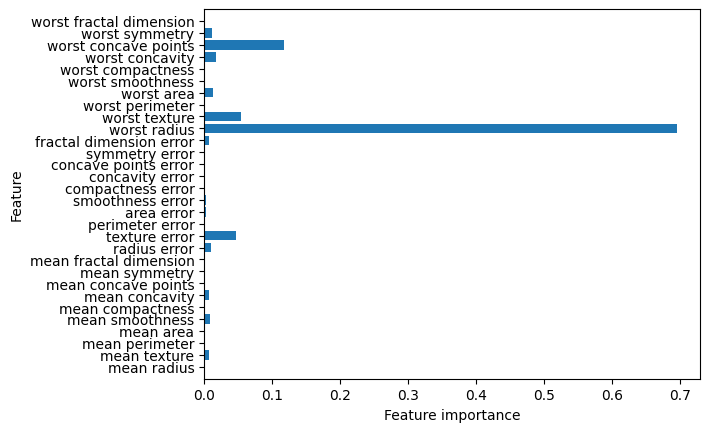

In [235]:
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(tree)

## 3. 랜덤 포레스트(Random Forest)

- DT를 기반으로, Ensemble 모형 중 Bagging을 적용

- 장점
1) 분류, 회귀에 사용
2) 좋은 성능과 빠른 계산
3) 대용량 데이터에서 활용, Feature가 많을 때도 잘 활용
- 단점
1) DT 개수 증가에 따른 계산 비용
2) 과적합

- 배깅(Bagging)
 1) 중복을 허용한 리샘플링(resampling)을 부트스트래핑(boostraping)의 한 종류
 2) 100개 데이터 중 75개 데이터를 학습할 경우, 배깅을 하면 복원추출을 통해서 여러 세트의 학습데이터(n=75)를 추출할 수 있음
 3) 앙상블 모델은 결과들에 대한 편차가 크지 않고 안정적인 결과 제공
 4) 학습데이터의 Bias를 해결은 못하지만, Unseen data에 대한 예측 시 좋은 성능, 노이즈 및 이상치에 대해서도 좋은 성능


<figure>
    <img src='https://miro.medium.com/max/1678/1*Wf91XObaX2zwow7mMwDmGw.png' width=700 height=300>
</figure>


- Hyperparameter
 1) n_estimators: 랜덤 포레스트 안의 결정 트리 갯수, 많으면 좋지만 계산 비용
 2) max_features: 무작위로 선택할 Feature의 개수, Default는 10, max_features=n_features이면 30개의 feature 중 30개의 feature 모두를 선택해 결정 트리. bootstrap=True (default)이면 30개의 feature에서 복원 추출로 30개. max_features 값이 크면 랜덤 포레스트의 트리들이 비슷한 feature를 갖게 되어 가장 중요한 feature에 맞게 예측되며, max_features 값이 작다면 랜덤 포레스트의 트리들이 서로 다르며 과적합은 감소

 3) max_depth : 트리의 깊이
 4) min_samples_leaf : 리프노드가 되기 위한 최소한의 샘플 데이터 수
 5) min_samples_split : 노드를 분할하기 위한 최소한의 데이터 수
 6) max_leaf_nodes : 리프노드의 최대 개수




### 3.1. 가상 데이터로 연습

In [236]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

x, y = make_moons(n_samples=100, noise=0.25, random_state=3) # noise: Standard deviation of Gaussian noise added to the data.
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42)
forest = RandomForestClassifier(n_estimators=5, n_jobs=-1, random_state=42) # n_estimators: 사용할 tree수
forest.fit(x_train, y_train)
forest.score(x_train, y_train)
forest.predict(x_test)

array([1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1])

In [237]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                    stratify=cancer.target, random_state=0)
n_feature = cancer.data.shape[1]

rf = RandomForestClassifier().fit(x_train, y_train)
rf.score( x_train,y_train)
rf.predict( x_test)

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0])

- 변수 중요도 시각화

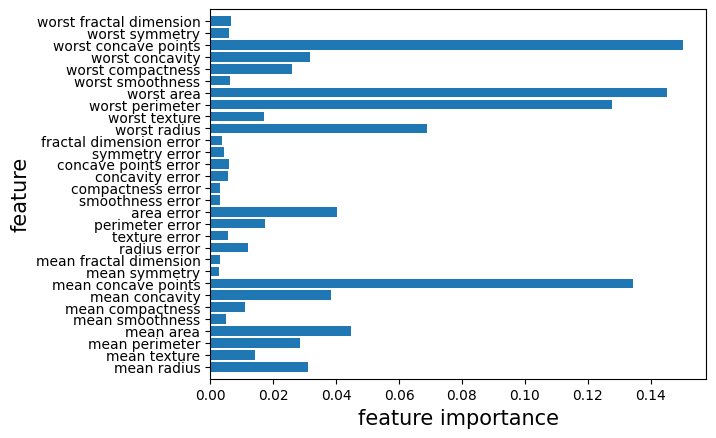

In [238]:
index = np.arange(n_feature)
forest = RandomForestClassifier(n_estimators=100, n_jobs=-1)
forest.fit(x_train, y_train)

import matplotlib.pyplot as plt
plt.barh(index, forest.feature_importances_, align='center')
plt.yticks(index, cancer.feature_names)
plt.ylim(-1, n_feature)
plt.xlabel('feature importance', size=15)
plt.ylabel('feature', size=15)
plt.show()

### 3.4. RF와 K-fold CV
- cross validation: 데이터셋을 k개의 subset으로 구분 후 k-1개의 subset을 train을 위해, 나머지 하나의 subset을 test를 위해 사용
  - 일반적으로 K=10을 사용하나, 데이터셋이 클 경우 계산 속도를 고려하여 k의 값을 줄이기도 함
  - 데이터셋이 많지 않을 경우 여러 번 샘플링하여 검증하는 과정을 거칠 수 있음
- cross validation을 사용할 경우 imbalanced data에 민감할 수 있음
  - class가 유사한 경우 `from sklearn.model_selection import KFold`을 통해 일반적인 kfold 사용
  - imbalanced인 경우 `from sklearn.model_selection import StratifiedKFold`을 통해 class의 수를 고려하여 kfold cv를 진행

In [239]:
from sklearn.model_selection import cross_validate
# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np
import warnings
warnings.filterwarnings(action='ignore')
# kfold = KFold(n_splits=10, shuffle=True, random_state=312) # K-Fold 객체 생성
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=312) # stratified K-Fold 객체 생성


- rf+cv

In [240]:
model_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
#penalty: 'l1', 'l2', 'elasticnet', 'none' (default: l2)
#fit_intercept: True, False (default: True)

# Stratified k-fold CV
# Accuracy 기준: cross_val_score(model, featrues, target, cross validation)
scores = cross_validate(model_rf, x_train, y_train, cv=kfold, # (model, featrues, target, cross validation)
                        scoring=['accuracy', 'recall', 'precision', 'f1', 'roc_auc'])
{k: np.mean(v) for k, v in scores.items()}



{'fit_time': np.float64(0.11510088443756103),
 'score_time': np.float64(0.04488043785095215),
 'test_accuracy': np.float64(0.967109634551495),
 'test_recall': np.float64(0.9773504273504274),
 'test_precision': np.float64(0.970839305011719),
 'test_f1': np.float64(0.9736943910695299),
 'test_roc_auc': np.float64(0.9960202991452991)}

In [241]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(model_rf, x_train, y_train, cv=kfold)

- logit+CV

In [242]:
model_logit = LogisticRegression()
#penalty: 'l1', 'l2', 'elasticnet', 'none' (default: l2)
#fit_intercept: True, False (default: True)

# Stratified k-fold CV
# Accuracy 기준: cross_val_score(model, featrues, target, cross validation)
scores = cross_validate(model_logit, x_train, y_train, cv=kfold, # (model, featrues, target, cross validation)
                        scoring=['accuracy', 'recall', 'precision', 'f1', 'roc_auc'])
{k: np.mean(v) for k, v in scores.items()}



{'fit_time': np.float64(0.01891169548034668),
 'score_time': np.float64(0.0053619384765625),
 'test_accuracy': np.float64(0.9508859357696566),
 'test_recall': np.float64(0.9665242165242164),
 'test_precision': np.float64(0.9565801790801791),
 'test_f1': np.float64(0.9606763734499001),
 'test_roc_auc': np.float64(0.9888443732193734)}

In [243]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(model_logit, x_train, y_train, cv=kfold)

- Grid Search CV

In [244]:
# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
rf_params = {"n_estimators": [50,100,150,200,250], "max_depth": list(range(2,4,1))}
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)),
              "min_samples_leaf": list(range(5,7,1))}

grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(x_train, y_train)
tree_clf = grid_tree.best_estimator_  # tree best estimator

grid_rf = GridSearchCV(RandomForestClassifier(), rf_params)
grid_rf.fit(x_train, y_train) # best estimator
rf_searched = grid_rf.best_estimator_

## 4. K-Nearest Neighbors

- 장점
  - 쉬운 알고리즘
  - hyperparameter 튜닝 없음
- 단점
  - Observation 증가에 따른 계산 비용
  - pre-processing을 잘하지 않으면 좋은 성능을 기대하기 어려움-> 거리 계산
  - feature의 값이 대부분 0인 데이터셋, Sparse인 경우 성능 이슈

In [245]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [246]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [247]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [248]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [249]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [250]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [251]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(iris.data,iris.target,test_size = 0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [252]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [253]:
print('accuracy : {:.2f}'.format(knn.score(X_test,y_test)))

accuracy : 1.00


In [254]:
#k값에 따른 성능 비교



In [255]:
#Scaling의 적용


In [256]:
#sp500_tm.csv 이용

## 5. Navie Bayes
### 5.1. Overview

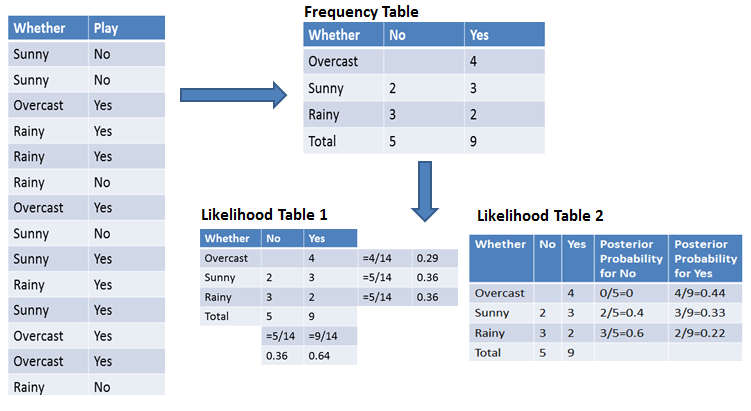

- Bayes 정리를 활용한 분류
- Frequency Table: 데이터에서의 빈도
- Likelihood Table 1: 각 Feature X 각 Label에 대한 확률
- Likelihood Table 2는 각 Feature에 대한 사후 확률

- 예: 날씨가 Overcast(흐린)
 - P(Yes|overcast) = P(overcast|Yes) * P(Yes)/P(overcast)
 1. 사전확률(Prior Probability)

    P(overcast) = 4/14 = 0.29

    P(Yes) = 9/14 = 0.64

 2. 사후 확률(posterior probability)

    P(Overcast|NO) = 0/9 = 0

 3. 베이즈 정리에 대입

    P(NO|overcast) = P(overcast|NO) * (P(No) / P(overcast)) = 0*(0.36 / 0.29) = 0

 - P(Yes|Overcast) = 1, P(No|Overcast) = 0
 - 날씨가 Overcast일 때 축구를 하는 확률은 0, 축구를 하지 않을 확률은 1
 - 두 확률을 비교한 뒤 더 높은 확률의 Label로 분류



- Feature가 2개 이상인 경우

<figure>
<img src = 'https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FYGLmm%2FbtqwIYLAj80%2FN2C1tFlYC9zNzvUKjy9tgk%2Fimg.png'>


 1. 사전 확률

    P(Yes) = 9/14 = 0.64

 2. 사후 확률

    P(Overcast|Yes) = 4/9 = 0.44

    P(Mild|Yes) = 4/9 = 0.44

 3. 베이즈 공식에 대입

    P(Weather=Overcast, Temp=Mild | Play=Yes) = P(Overcast|Yes) P(Mild|Yes) = 0.44 * 0.44 = 0.1936

    P(Paly=Yes | Weather=Overcast, Temp=Mild) = P(Weather=Overcast, Temp=Mild | Play=Yes) P(Play=Yes) / P(Weather=Overcast, Temp=Mild)= 0.1936 * 0.64 / 0.1224 = 1

- 장점

1. 간단하고, 빠르며, 정확한 모델

2. computation cost가 작음

3. 큰 데이터셋에 적합

4. 연속형보다 이산형 데이터에서 성능이 좋음, DTM?

5. Multiple class 예측을 위해서도 사용할 수 있음

- 단점: feature 간의 독립성을 가정
 - **features are conditionally independent**
 - 실제 데이터에서 모든 feature가 독립인 경우는 없기에 "Naive한 가정"


### 5.2. 모형 구축

In [257]:
# Assigning features and label variables
weather=['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny',
'Rainy','Sunny','Overcast','Overcast','Rainy']
temp=['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild']

play=['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']

In [258]:
# Import LabelEncoder
from sklearn import preprocessing

#creating labelEncoder
le = preprocessing.LabelEncoder()
# Converting string labels into numbers.|
weather_encoded=le.fit_transform(weather)
print(weather_encoded)

[2 2 0 1 1 1 0 2 2 1 2 0 0 1]


In [259]:
# Converting string labels into numbers
temp_encoded=le.fit_transform(temp)
label=le.fit_transform(play)
print("Temp:",temp_encoded)
print("Play:",label)

Temp: [1 1 1 2 0 0 0 2 0 2 2 2 1 2]
Play: [0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [260]:
import pandas as pd
features = pd.DataFrame({"temp":temp_encoded, "weather":weather_encoded})
print(features)

    temp  weather
0      1        2
1      1        2
2      1        0
3      2        1
4      0        1
5      0        1
6      0        0
7      2        2
8      0        2
9      2        1
10     2        2
11     2        0
12     1        0
13     2        1


In [261]:
#Import Gaussian Naive Bayes model
from sklearn.naive_bayes import GaussianNB

#Create a Gaussian Classifier
model = GaussianNB()

# Train the model using the training sets
model.fit(features,label)

#Predict Output
predicted= model.predict([[0,2]]) # 0:Overcast, 2:Mild
print("Predicted Value:", predicted)

Predicted Value: [0]


- NB 연습(target의 범주가 3 이상)

In [262]:
#Import scikit-learn dataset library
from sklearn import datasets
wine = datasets.load_wine()

# print the names of the 13 features
print("Features: ", wine.feature_names)

# print the label type of wine(class_0, class_1, class_2)
print("Labels: ", wine.target_names)

Features:  ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Labels:  ['class_0' 'class_1' 'class_2']


In [263]:
wine.data.shape

(178, 13)

In [264]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.3, random_state=109)

#Import Gaussian Naive Bayes model
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

from sklearn import metrics
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9074074074074074


### 5.3. NB 연습


- NB의 종류
 1. GaussianNB → Feature가 연속형
 2. CategoricalNB → Feature가 범주형
 3. MultinomialNB → DTM에 활용